In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from arch import arch_model
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# Download and Calculate Returns
ticker = "^GSPC"
data = yf.download(ticker, start="2006-01-01", end="2026-02-19", multi_level_index=False)
vix_data = yf.download("^VIX", start="2006-01-01", end="2026-02-19", multi_level_index=False)

data['Return'] = 100 * np.log(data['Close'] / data['Close'].shift(1))
data.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [2]:
# EGARCH(1,1) with Student's t-distribution
model = arch_model(data['Return'], vol='EGARCH', p=1, o=1, q=1, dist='t')
res = model.fit(disp='off')

# Scaling and Merging
data['GARCH_Ann'] = res.conditional_volatility * np.sqrt(252)
comparison = pd.concat([data['GARCH_Ann'], vix_data['Close']], axis=1).dropna()
comparison.columns = ['GARCH', 'VIX']
comparison['VRP'] = comparison['VIX'] - comparison['GARCH']

print(res.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                       Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -6550.00
Distribution:      Standardized Student's t   AIC:                           13112.0
Method:                  Maximum Likelihood   BIC:                           13151.2
                                              No. Observations:                 5062
Date:                      Mon, Mar 02 2026   Df Residuals:                     5061
Time:                              17:27:29   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

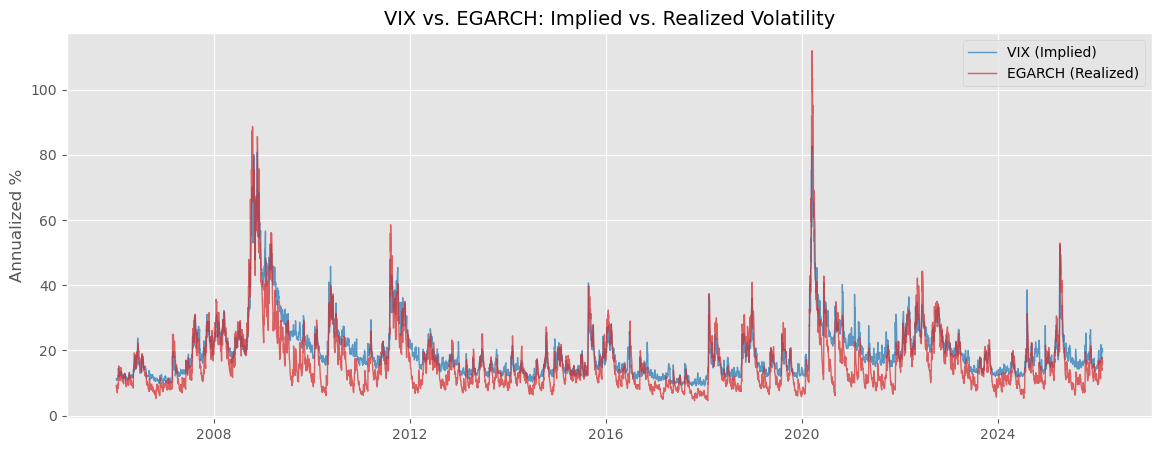

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(comparison.index, comparison['VIX'], color='tab:blue', lw=1, label='VIX (Implied)', alpha=0.7)
plt.plot(comparison.index, comparison['GARCH'], color='tab:red', lw=1, label='EGARCH (Realized)', alpha=0.7)
plt.title('VIX vs. EGARCH: Implied vs. Realized Volatility', fontsize=14)
plt.ylabel('Annualized %')
plt.legend()
plt.show()

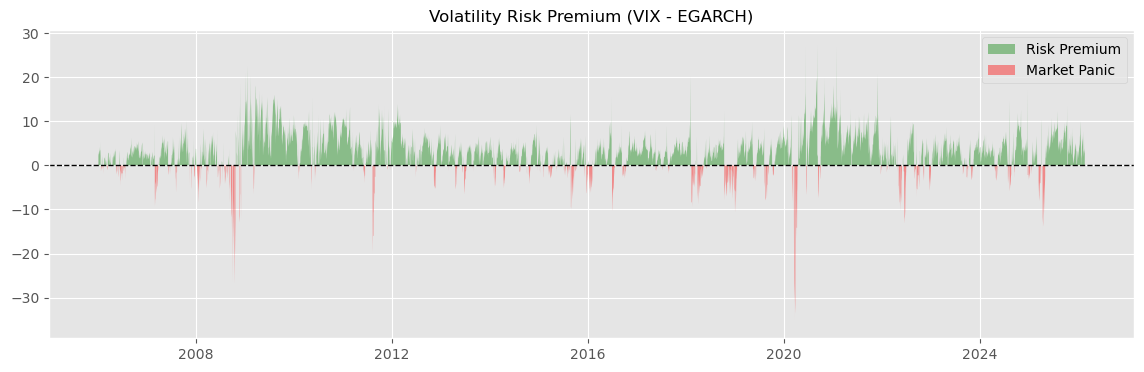

In [ ]:
plt.figure(figsize=(14, 4))
plt.fill_between(comparison.index, comparison['VRP'], 0, 
                 where=(comparison['VRP'] >= 0), facecolor='green', alpha=0.4, label='Risk Premium')
plt.fill_between(comparison.index, comparison['VRP'], 0, 
                 where=(comparison['VRP'] < 0), facecolor='red', alpha=0.4, label='Market Panic')
plt.axhline(0, color='black', lw=1, ls='--')
plt.title('Volatility Risk Premium (VIX - EGARCH)', fontsize=12)
plt.legend()
plt.show()

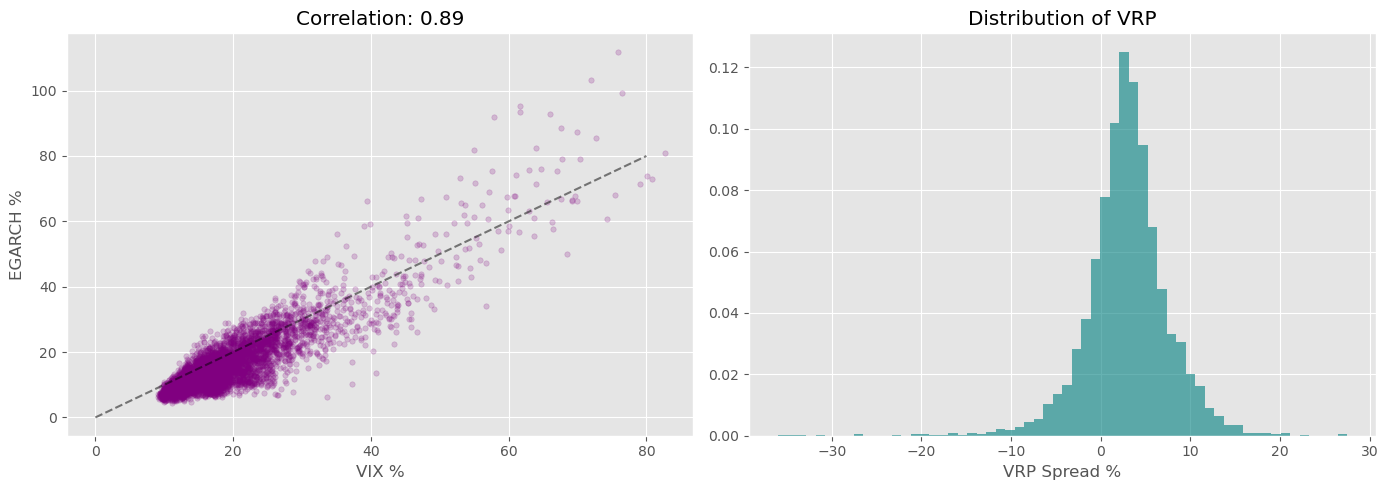

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Plot
ax1.scatter(comparison['VIX'], comparison['GARCH'], alpha=0.2, s=15, color='purple')
ax1.plot([0, 80], [0, 80], 'k--', alpha=0.5) # 1:1 Line
ax1.set_title(f'Correlation: {comparison["VIX"].corr(comparison["GARCH"]):.2f}')
ax1.set_xlabel('VIX %')
ax1.set_ylabel('EGARCH %')

# VRP Histogram
ax2.hist(comparison['VRP'], bins=60, color='teal', alpha=0.6, density=True)
ax2.set_title('Distribution of VRP')
ax2.set_xlabel('VRP Spread %')

plt.tight_layout()
plt.show()